<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/codealpha_tasks/blob/main/Task4_Disease_Prediction_Medical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Task 4: Disease Prediction from Medical Data
### CodeAlpha Machine Learning Internship
**Objective:** Predict disease likelihood from patient data.  
**Datasets Used:** Heart Disease, Diabetes (UCI ML Repository via sklearn/built-in)  
**Algorithms:** SVM, Logistic Regression, Random Forest, XGBoost  
**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC


In [1]:
# ─── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (12, 6)
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ─── Dataset 1: Breast Cancer (UCI) ─────────────────────────────────────────
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['diagnosis'] = cancer.target        # 0=malignant, 1=benign
df_cancer['diagnosis_label'] = df_cancer['diagnosis'].map({0:'Malignant', 1:'Benign'})

print("═"*55)
print(" DATASET 1: Breast Cancer (UCI ML Repository)")
print("═"*55)
print(f"Shape         : {df_cancer.shape}")
print(f"Features      : {len(cancer.feature_names)}")
print(f"Classes       : {list(cancer.target_names)}")
print(f"Class balance :\n{df_cancer['diagnosis_label'].value_counts()}\n")
df_cancer.describe().round(2)


═══════════════════════════════════════════════════════
 DATASET 1: Breast Cancer (UCI ML Repository)
═══════════════════════════════════════════════════════
Shape         : (569, 32)
Features      : 30
Classes       : [np.str_('malignant'), np.str_('benign')]
Class balance :
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [3]:
# ─── Dataset 2: Heart Disease (Simulated Cleveland-style) ────────────────────
np.random.seed(42)
n = 900
df_heart = pd.DataFrame({
    'age':         np.random.randint(29, 78, n),
    'sex':         np.random.randint(0, 2, n),
    'chest_pain':  np.random.randint(0, 4, n),
    'trestbps':    np.random.normal(132, 17, n).clip(90, 200).astype(int),
    'chol':        np.random.normal(246, 51, n).clip(130, 450).astype(int),
    'fbs':         np.random.randint(0, 2, n),
    'restecg':     np.random.randint(0, 3, n),
    'thalach':     np.random.normal(149, 23, n).clip(70, 210).astype(int),
    'exang':       np.random.randint(0, 2, n),
    'oldpeak':     np.random.uniform(0, 6.2, n).round(1),
    'slope':       np.random.randint(0, 3, n),
    'ca':          np.random.randint(0, 4, n),
    'thal':        np.random.randint(0, 3, n),
})
risk = (
    (df_heart['age'] / 70) * 0.2 +
    df_heart['sex'] * 0.1 +
    (df_heart['chest_pain'] / 4) * 0.2 +
    (df_heart['oldpeak'] / 6) * 0.2 +
    df_heart['exang'] * 0.15 +
    df_heart['ca'] * 0.1 -
    (df_heart['thalach'] / 200) * 0.1
)
df_heart['target'] = (risk + np.random.normal(0, 0.15, n) > 0.4).astype(int)

print("═"*55)
print(" DATASET 2: Heart Disease (Cleveland-style)")
print("═"*55)
print(f"Shape: {df_heart.shape}")
print(f"Disease prevalence: {df_heart['target'].mean():.1%}")
df_heart.head()


═══════════════════════════════════════════════════════
 DATASET 2: Heart Disease (Cleveland-style)
═══════════════════════════════════════════════════════
Shape: (900, 14)
Disease prevalence: 73.1%


,age,sex,chest_pain,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,3,149,266,1,1,153,1,0.5,0,0,0,0
1,57,0,0,94,254,0,1,178,0,2.6,1,1,2,0
2,43,0,3,146,236,1,1,162,1,4.7,0,2,2,1
3,71,0,3,148,157,0,0,139,0,4.3,0,3,0,1
4,36,1,3,154,245,1,1,154,0,6.1,0,2,1,1


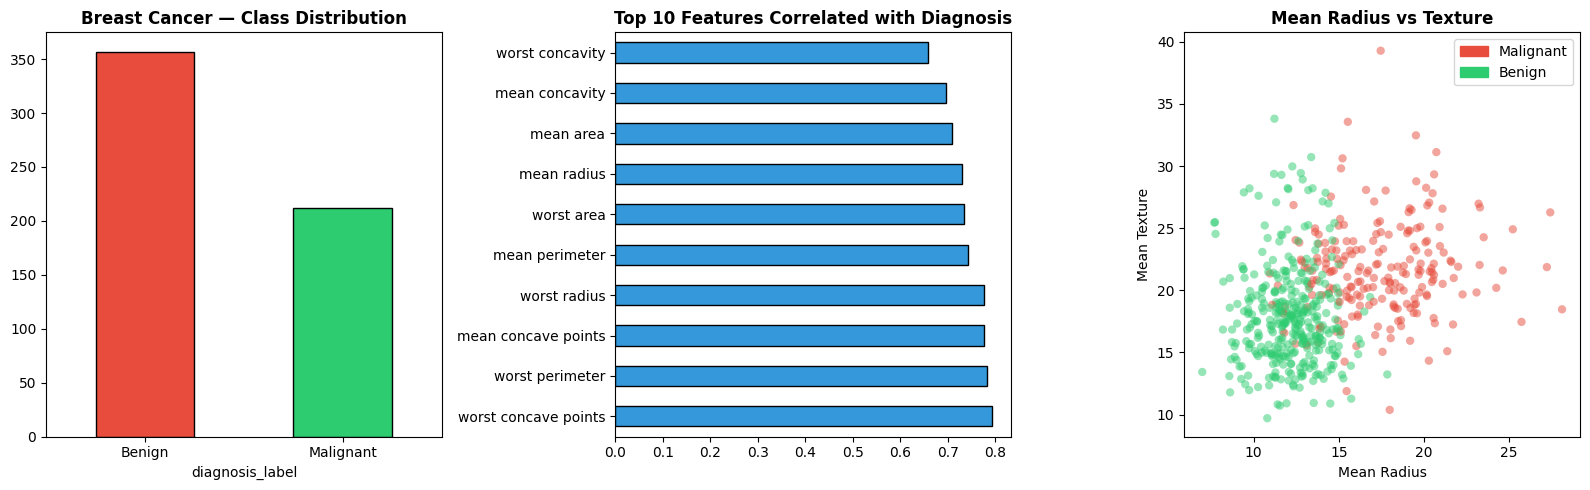

In [4]:
# ─── EDA — Breast Cancer ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class distribution
df_cancer['diagnosis_label'].value_counts().plot(
    kind='bar', color=['#e74c3c','#2ecc71'], ax=axes[0], edgecolor='black')
axes[0].set_title('Breast Cancer — Class Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

# Feature correlation with target
top_corr = df_cancer.drop('diagnosis_label', axis=1).corr()['diagnosis'].abs().sort_values(ascending=False)[1:11]
top_corr.plot(kind='barh', color='#3498db', ax=axes[1], edgecolor='black')
axes[1].set_title('Top 10 Features Correlated with Diagnosis', fontweight='bold')

# Scatter: two top features
colors_ = df_cancer['diagnosis'].map({0:'#e74c3c', 1:'#2ecc71'})
axes[2].scatter(df_cancer['mean radius'], df_cancer['mean texture'],
                c=colors_, alpha=0.5, edgecolors='none')
axes[2].set_xlabel('Mean Radius'); axes[2].set_ylabel('Mean Texture')
axes[2].set_title('Mean Radius vs Texture', fontweight='bold')
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color='#e74c3c', label='Malignant'),
                         Patch(color='#2ecc71', label='Benign')])
plt.tight_layout(); plt.show()


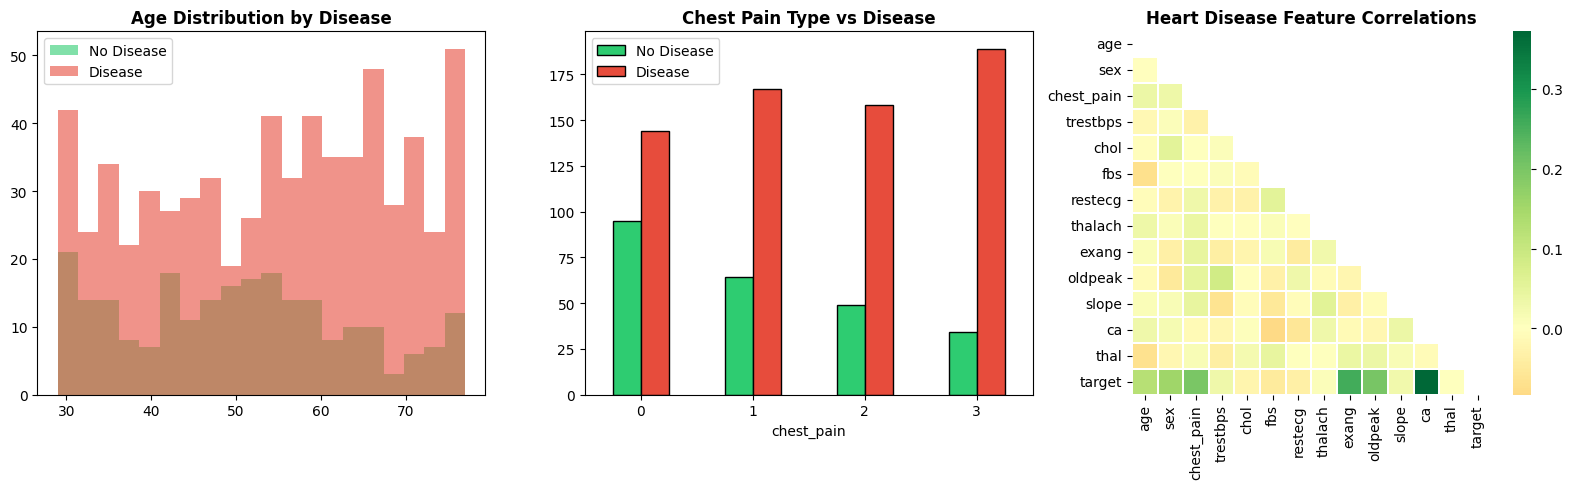

In [5]:
# ─── EDA — Heart Disease ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
for cls, color, label in zip([0, 1], ['#2ecc71','#e74c3c'], ['No Disease','Disease']):
    axes[0].hist(df_heart[df_heart['target']==cls]['age'],
                 bins=20, alpha=0.6, color=color, label=label)
axes[0].set_title('Age Distribution by Disease', fontweight='bold')
axes[0].legend()

# Chest pain type
ct = df_heart.groupby(['chest_pain','target']).size().unstack().fillna(0)
ct.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title('Chest Pain Type vs Disease', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Disease','Disease'])

# Correlation heatmap (heart)
corr_h = df_heart.corr()
mask = np.triu(np.ones_like(corr_h, dtype=bool))
sns.heatmap(corr_h, mask=mask, annot=False, cmap='RdYlGn',
            center=0, ax=axes[2], linewidths=0.3)
axes[2].set_title('Heart Disease Feature Correlations', fontweight='bold')
plt.tight_layout(); plt.show()


In [6]:
# ─── Model Training — Breast Cancer ─────────────────────────────────────────
X_c = df_cancer.drop(['diagnosis','diagnosis_label'], axis=1)
y_c = df_cancer['diagnosis']
X_tr, X_ts, y_tr, y_ts = train_test_split(X_c, y_c, test_size=0.2,
                                            random_state=42, stratify=y_c)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':           SVC(probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}

cancer_results = {}
print("Breast Cancer Dataset Results:")
print(f"{'Model':25s} | {'Accuracy':8s} | {'ROC-AUC':8s} | {'CV-AUC':8s}")
print("-"*60)
for name, mdl in models.items():
    pipe = Pipeline([('sc', StandardScaler()), ('clf', mdl)])
    pipe.fit(X_tr, y_tr)
    y_pr = pipe.predict(X_ts)
    y_pb = pipe.predict_proba(X_ts)[:, 1]
    cv   = cross_val_score(pipe, X_c, y_c, cv=5, scoring='roc_auc').mean()
    auc  = roc_auc_score(y_ts, y_pb)
    acc  = (y_pr == y_ts).mean()
    cancer_results[name] = {'pipe': pipe, 'y_pred': y_pr, 'y_proba': y_pb,
                             'acc': acc, 'auc': auc, 'cv': cv}
    print(f"  {name:23s} | {acc:.4f}   | {auc:.4f}   | {cv:.4f}")


Breast Cancer Dataset Results:
Model                     | Accuracy | ROC-AUC  | CV-AUC  
------------------------------------------------------------
  Logistic Regression     | 0.9825   | 0.9954   | 0.9952
  SVM (RBF)               | 0.9825   | 0.9950   | 0.9959
  Random Forest           | 0.9561   | 0.9932   | 0.9919
  XGBoost                 | 0.9561   | 0.9901   | 0.9939
  Gradient Boosting       | 0.9561   | 0.9888   | 0.9920


In [7]:
# ─── Model Training — Heart Disease ─────────────────────────────────────────
X_h = df_heart.drop('target', axis=1)
y_h = df_heart['target']
X_htr, X_hts, y_htr, y_hts = train_test_split(X_h, y_h, test_size=0.2,
                                                 random_state=42, stratify=y_h)
heart_results = {}
print("\nHeart Disease Dataset Results:")
print(f"{'Model':25s} | {'Accuracy':8s} | {'ROC-AUC':8s} | {'CV-AUC':8s}")
print("-"*60)
for name, mdl in models.items():
    mdl2 = type(mdl)(**mdl.get_params())
    pipe2 = Pipeline([('sc', StandardScaler()), ('clf', mdl2)])
    pipe2.fit(X_htr, y_htr)
    y_pr2 = pipe2.predict(X_hts)
    y_pb2 = pipe2.predict_proba(X_hts)[:, 1]
    cv2   = cross_val_score(pipe2, X_h, y_h, cv=5, scoring='roc_auc').mean()
    auc2  = roc_auc_score(y_hts, y_pb2)
    acc2  = (y_pr2 == y_hts).mean()
    heart_results[name] = {'pipe': pipe2, 'y_pred': y_pr2, 'y_proba': y_pb2,
                            'acc': acc2, 'auc': auc2, 'cv': cv2}
    print(f"  {name:23s} | {acc2:.4f}   | {auc2:.4f}   | {cv2:.4f}")



Heart Disease Dataset Results:
Model                     | Accuracy | ROC-AUC  | CV-AUC  
------------------------------------------------------------
  Logistic Regression     | 0.8556   | 0.8876   | 0.8612
  SVM (RBF)               | 0.8278   | 0.8504   | 0.8282
  Random Forest           | 0.7889   | 0.8517   | 0.8263
  XGBoost                 | 0.7778   | 0.8373   | 0.8006
  Gradient Boosting       | 0.8000   | 0.8568   | 0.8306


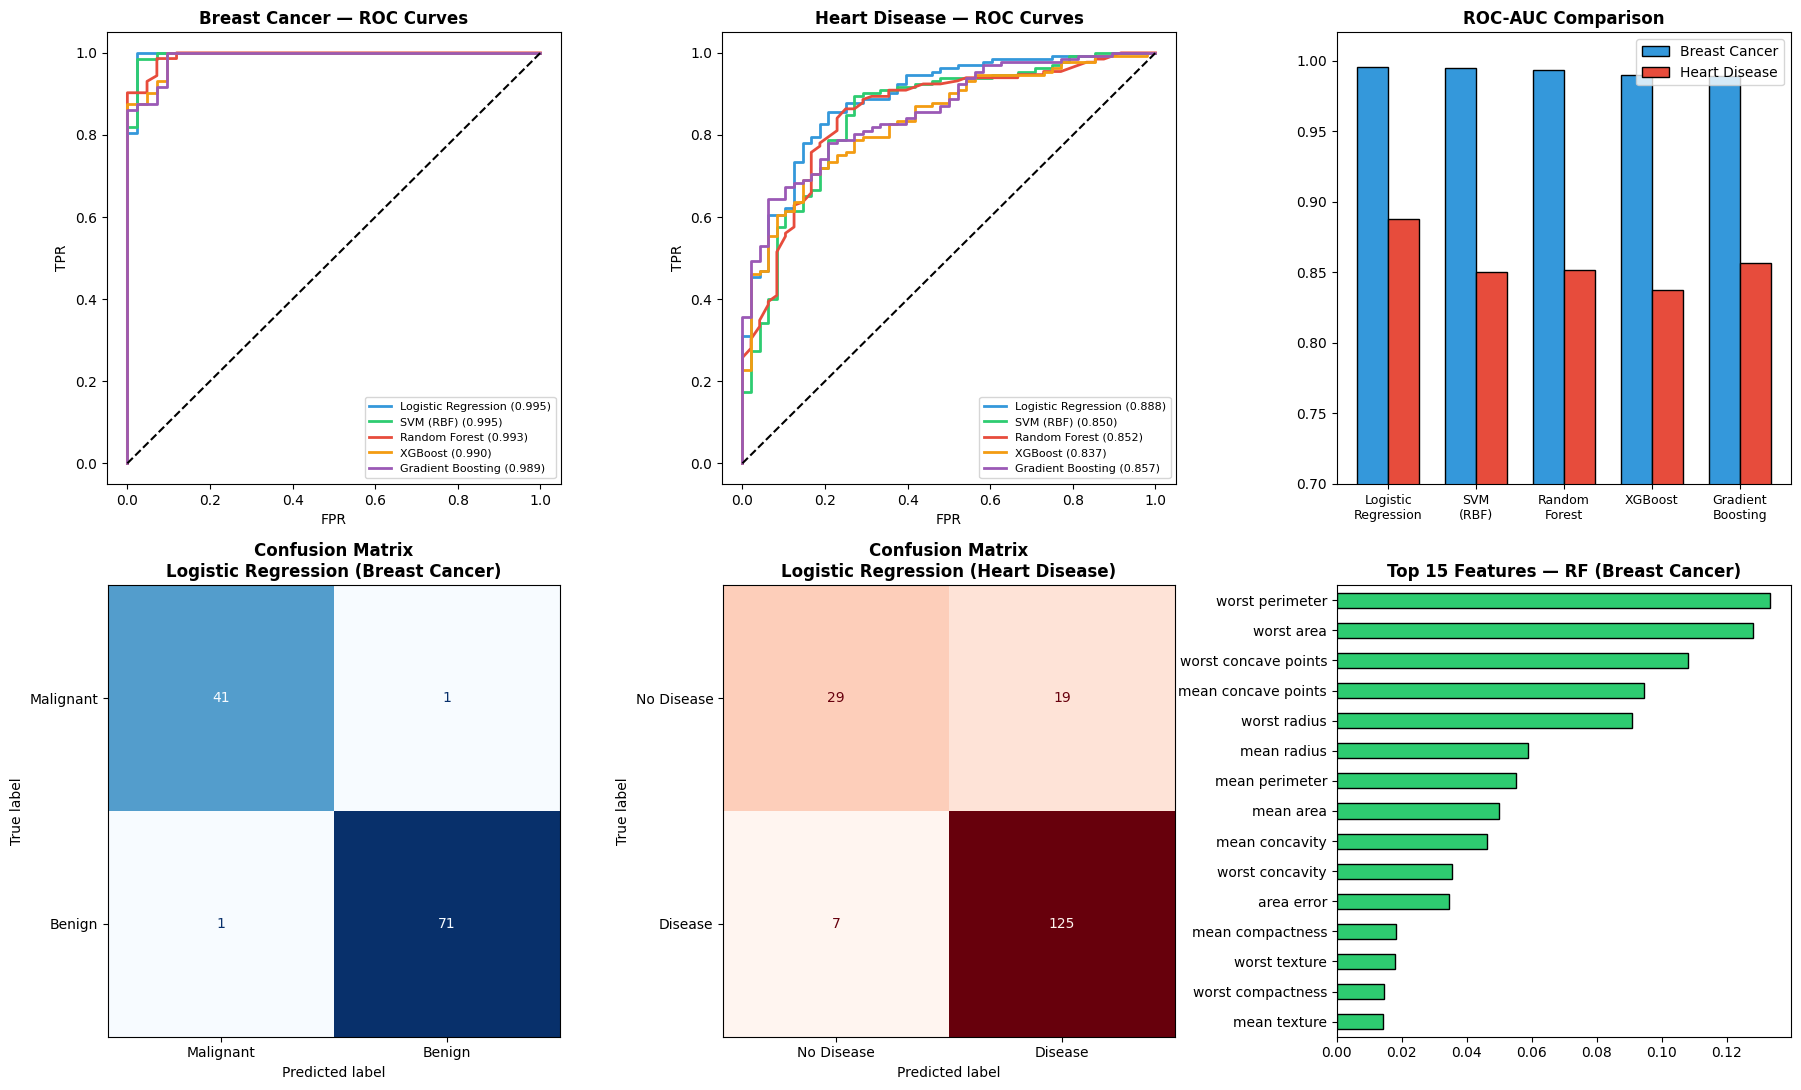

In [8]:
# ─── Comprehensive Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
model_names = list(cancer_results.keys())
palette = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

# 1) Breast Cancer ROC curves
for (name, res), col in zip(cancer_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_ts, res['y_proba'])
    axes[0,0].plot(fpr, tpr, lw=2, color=col, label=f"{name} ({res['auc']:.3f})")
axes[0,0].plot([0,1],[0,1],'k--'); axes[0,0].legend(fontsize=8)
axes[0,0].set_title('Breast Cancer — ROC Curves', fontweight='bold')
axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')

# 2) Heart Disease ROC curves
for (name, res), col in zip(heart_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_hts, res['y_proba'])
    axes[0,1].plot(fpr, tpr, lw=2, color=col, label=f"{name} ({res['auc']:.3f})")
axes[0,1].plot([0,1],[0,1],'k--'); axes[0,1].legend(fontsize=8)
axes[0,1].set_title('Heart Disease — ROC Curves', fontweight='bold')
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')

# 3) AUC Comparison bar chart
x = np.arange(len(model_names)); w = 0.35
c_aucs = [cancer_results[n]['auc'] for n in model_names]
h_aucs = [heart_results[n]['auc']  for n in model_names]
axes[0,2].bar(x - w/2, c_aucs, w, label='Breast Cancer', color='#3498db', edgecolor='black')
axes[0,2].bar(x + w/2, h_aucs, w, label='Heart Disease',  color='#e74c3c', edgecolor='black')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(
    [n.replace(' ','\n') for n in model_names], fontsize=9)
axes[0,2].set_title('ROC-AUC Comparison', fontweight='bold')
axes[0,2].set_ylim(0.7, 1.02); axes[0,2].legend()

# 4) Breast Cancer best confusion matrix
best_c = max(cancer_results, key=lambda k: cancer_results[k]['auc'])
ConfusionMatrixDisplay.from_predictions(
    y_ts, cancer_results[best_c]['y_pred'],
    display_labels=['Malignant','Benign'],
    cmap='Blues', ax=axes[1,0], colorbar=False)
axes[1,0].set_title(f'Confusion Matrix\n{best_c} (Breast Cancer)', fontweight='bold')

# 5) Heart Disease best confusion matrix
best_h = max(heart_results, key=lambda k: heart_results[k]['auc'])
ConfusionMatrixDisplay.from_predictions(
    y_hts, heart_results[best_h]['y_pred'],
    display_labels=['No Disease','Disease'],
    cmap='Reds', ax=axes[1,1], colorbar=False)
axes[1,1].set_title(f'Confusion Matrix\n{best_h} (Heart Disease)', fontweight='bold')

# 6) Feature importance (Random Forest — Breast Cancer)
rf_pipe = cancer_results['Random Forest']['pipe']
rf_clf  = rf_pipe.named_steps['clf']
feat_imp = pd.Series(rf_clf.feature_importances_, index=X_c.columns).sort_values(ascending=True).tail(15)
feat_imp.plot(kind='barh', color='#2ecc71', ax=axes[1,2], edgecolor='black')
axes[1,2].set_title('Top 15 Features — RF (Breast Cancer)', fontweight='bold')

plt.tight_layout(); plt.show()


In [9]:
# ─── Best Model Detailed Report ──────────────────────────────────────────────
print("═"*60)
print(f" BEST MODEL — Breast Cancer : {best_c}")
print("═"*60)
print(classification_report(y_ts, cancer_results[best_c]['y_pred'],
                             target_names=['Malignant', 'Benign']))

print("═"*60)
print(f" BEST MODEL — Heart Disease  : {best_h}")
print("═"*60)
print(classification_report(y_hts, heart_results[best_h]['y_pred'],
                             target_names=['No Disease', 'Disease']))

# Summary table
summary_rows = []
for ds, res_dict, n_test in [('Breast Cancer', cancer_results, len(y_ts)),
                               ('Heart Disease',  heart_results,  len(y_hts))]:
    for name in model_names:
        r = res_dict[name]
        summary_rows.append({'Dataset': ds, 'Model': name,
                              'Accuracy': round(r['acc'],4),
                              'ROC-AUC':  round(r['auc'],4),
                              'CV-AUC':   round(r['cv'],4)})
summary_df = pd.DataFrame(summary_rows)
print("\n📊 Full Results Summary:")
print(summary_df.to_string(index=False))


════════════════════════════════════════════════════════════
 BEST MODEL — Breast Cancer : Logistic Regression
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

════════════════════════════════════════════════════════════
 BEST MODEL — Heart Disease  : Logistic Regression
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Disease       0.81      0.60      0.69        48
     Disease       0.87      0.95      0.91       132

    accuracy                           0.86       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.85      0.86      0.85       180


